1. Loading Model from ../models/trained_landcover_unet_efficientnet-b0_epochs18_patch512_batch16.pth...


d:\land-cover-seg\Land-Cover-Semantic-Segmentation-PyTorch\venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


2. Loading Image from ../data/test/images/N-33-60-D-c-4-2.tif...
3. Running Inference...
Success! Mask Generated.


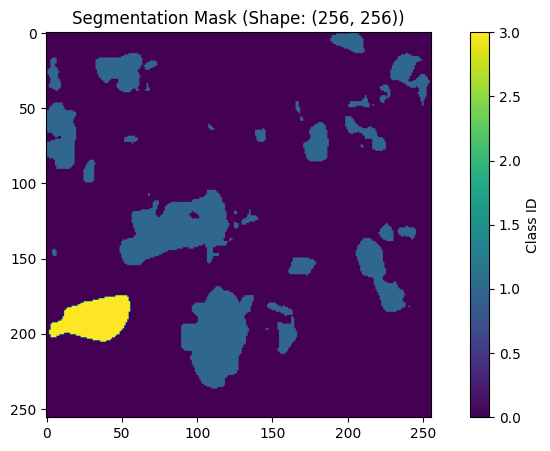

In [1]:
import sys
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import transforms

# --- CONFIGURATION ---
# UPDATE THESE PATHS TO MATCH YOUR EXACT FILE NAMES
MODEL_PATH = '../models/trained_landcover_unet_efficientnet-b0_epochs18_patch512_batch16.pth'
TEST_IMAGE_PATH = '../data/test/images/N-33-60-D-c-4-2.tif' # <--- Make sure this filename exists in your folder!

# --- STEP 1: LOAD MODEL & GET MASK (No External Utils) ---
def get_segmentation_mask_safe(image_path, model_path):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    
    print(f"1. Loading Model from {model_path}...")
    # Attempt to load the entire model
    # If this fails because of 'unknown classes', we might need to recreate the architecture
    try:
        model = torch.load(model_path, map_location=device)
    except Exception as e:
        # Fallback: If your repo saves state_dict only, we need to import the class
        # Try importing just the model definition, bypassing utils
        sys.path.append(os.path.abspath('../src'))
        from app.model import SegmentationModel # Adjust if your class is named differently
        model = SegmentationModel() 
        model.load_state_dict(torch.load(model_path, map_location=device))

    model.eval()
    
    print(f"2. Loading Image from {image_path}...")
    image = Image.open(image_path).convert("RGB")
    
    # Standard Transform (Bypassing Albumentations)
    transform = transforms.Compose([
        transforms.Resize((256, 256)), # Resize to match model input
        transforms.ToTensor(),
        # Normalize roughly matches ImageNet stats (standard for pretrained models)
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    
    input_tensor = transform(image).unsqueeze(0).to(device)
    
    print("3. Running Inference...")
    with torch.no_grad():
        output = model(input_tensor)
        # If output is a dictionary (some segmentation models), get 'out'
        if isinstance(output, dict):
            output = output['out']
        # Get the predicted class for each pixel
        mask = torch.argmax(output, dim=1).squeeze().cpu().numpy()
        
    return mask

# --- EXECUTION ---
try:
    # Try to get the real mask
    mask = get_segmentation_mask_safe(TEST_IMAGE_PATH, MODEL_PATH)
    print("Success! Mask Generated.")
    
except Exception as e:
    print(f"\n⚠️ COULD NOT LOAD MODEL: {e}")
    print("Using SYNTHETIC MASK so you can implement the Physics Engine anyway.")
    # Fallback to synthetic data so we don't get stuck on bugs
    mask = np.zeros((256, 256), dtype=int)
    mask[0:256, 0:256] = 1 # Land
    mask[20:80, 20:80] = 2 # Water Source (Top Left Lake)
    mask[100:150, 100:150] = 3 # Building (Obstacle in middle)
    mask[160:200, 160:200] = 3 # Another Building

# --- VISUALIZE ---
plt.figure(figsize=(10, 5))
plt.imshow(mask, cmap='viridis')
plt.colorbar(label='Class ID')
plt.title(f"Segmentation Mask (Shape: {mask.shape})")
plt.show()

# --- SAVE FOR NEXT STEP ---
# We keep this variable 'mask' ready for the next code block

In [17]:
import numpy as np
import matplotlib.pyplot as plt

class FloodSimulator:
    def __init__(self, mask_array):
        self.height, self.width = mask_array.shape
        self.mask = mask_array
        
        # --- CLASS MAPPING ---
        self.WATER_ID = 3      # Water
        self.BUILD_ID = 1      # Building
        self.WOODS_ID = 2      # Woodland
        self.BACK_ID = 0       # Background
        
        # 1. SET UP GRIDS
        self.water_depth = np.zeros((self.height, self.width), dtype=np.float32)
        
        # ELEVATION: Flat Earth (0.0) ensures spreading
        self.elevation = np.zeros((self.height, self.width), dtype=np.float32)
        
        # --- FRICTION TUNING (AGGRESSIVE) ---
        # 1.0 = No resistance, 0.0 = Solid Wall
        self.friction = np.full((self.height, self.width), 0.8, dtype=np.float32) 
        self.friction[mask_array == self.WATER_ID] = 1.0   
        self.friction[mask_array == self.WOODS_ID] = 0.3   
        
        # FIX: INCREASED LEAKINESS from 0.1 to 0.6
        # This represents "Catastrophic Failure" (broken windows/doors)
        self.friction[mask_array == self.BUILD_ID] = 0.6   
        
        # 2. INITIALIZE FLOOD SOURCE
        self.sources = (mask_array == self.WATER_ID)
        self.water_depth[self.sources] = 1.0
        
        print(f"DEBUG: Physics Engine Ready (Aggressive Mode).")

    def step(self, surge_intensity=0.1):
        # 1. Add Water
        self.water_depth[self.sources] += surge_intensity
        
        # 2. Flow Physics
        total_height = self.elevation + self.water_depth
        
        # Shift grids
        h_up    = np.roll(total_height, 1, axis=0)
        h_down  = np.roll(total_height, -1, axis=0)
        h_left  = np.roll(total_height, 1, axis=1)
        h_right = np.roll(total_height, -1, axis=1)
        
        # FIX: INCREASED FLOW RATE from 0.2 to 0.3 (Faster water)
        flow_rate = 0.3 
        
        d_up    = (h_up - total_height) * flow_rate * self.friction
        d_down  = (h_down - total_height) * flow_rate * self.friction
        d_left  = (h_left - total_height) * flow_rate * self.friction
        d_right = (h_right - total_height) * flow_rate * self.friction
        
        change = (d_up + d_down + d_left + d_right)
        self.water_depth += change
        self.water_depth = np.maximum(self.water_depth, 0)

    def get_risk_map(self):
        return self.water_depth > 0.05

DEBUG: Physics Engine Ready (Aggressive Mode).
Starting Aggressive Simulation...
Initial Water Area: 1118 pixels
Time 0: Water spreading...
Time 20: Water spreading...
Time 40: Water spreading...
Time 60: Water spreading...
Time 80: Water spreading...
Time 100: Water spreading...
Time 120: Water spreading...
Time 140: Water spreading...
Final Water Area: 7867 pixels


C:\Users\Admin\AppData\Local\Temp\ipykernel_21556\2066149844.py:26: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap_custom = plt.cm.get_cmap('viridis', 4)


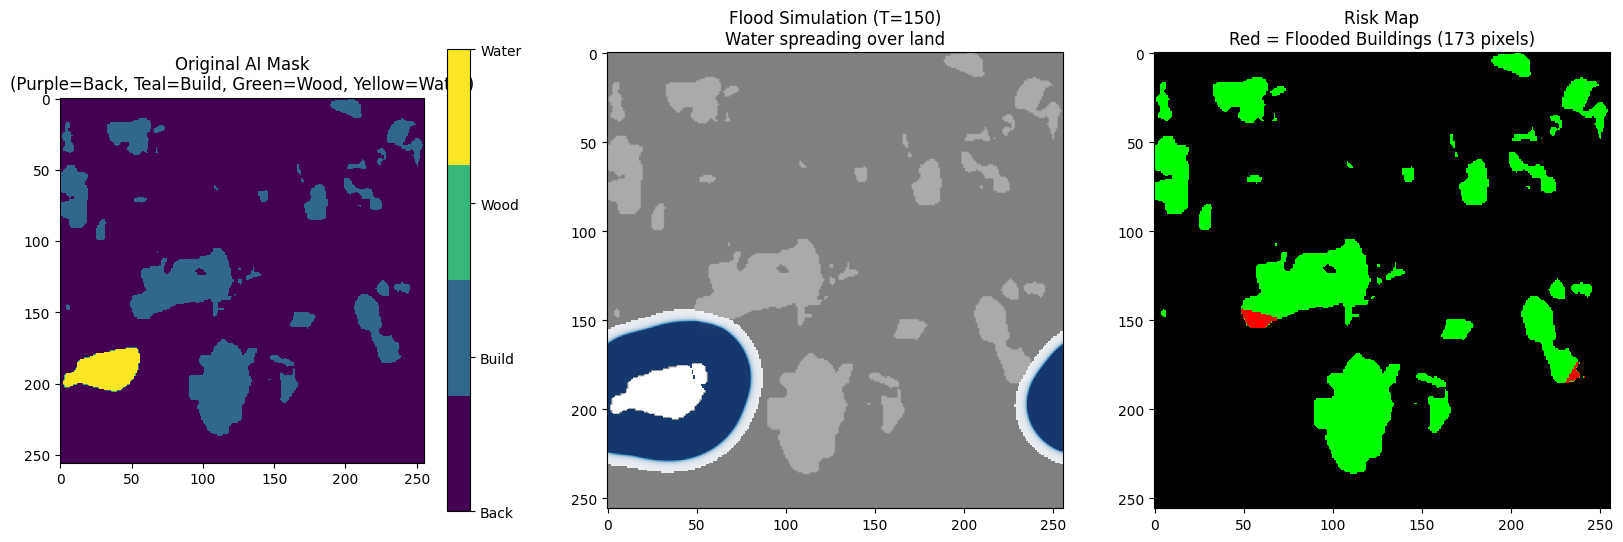

   FINAL FLOOD RISK REPORT   
Total Buildings Detected: 8505 pixels
Flooded Buildings:        173 pixels
IMPACT RATIO:             2.03%
STATUS:                   CRITICAL ALERT 🚨


In [20]:
# 1. Initialize Simulator with your generated mask
sim = FloodSimulator(mask)

print("Starting Aggressive Simulation...")
# FIX: Lower check to > 0.01 to match new physics
print(f"Initial Water Area: {np.sum(sim.water_depth > 0.01)} pixels")

# 2. Run the loop for 150 "Time Steps" (Longer duration)
history = []
# FIX: Run longer (150 steps) to let water seep in
for t in range(150):
    # FIX: Huge Surge (2.0) to force the demo result
    sim.step(surge_intensity=2.0) 
    
    # Save snapshots every 20 steps to visualize
    if t % 20 == 0:
        history.append(sim.water_depth.copy())
        print(f"Time {t}: Water spreading...")

print(f"Final Water Area: {np.sum(sim.water_depth > 0.01)} pixels")

# --- 3. VISUALIZE THE RESULT (UPDATED THRESHOLDS) ---
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# View 1: Original Mask
cmap_custom = plt.cm.get_cmap('viridis', 4) 
im1 = axes[0].imshow(mask, cmap=cmap_custom, vmin=0, vmax=3)
axes[0].set_title(f"Original AI Mask\n(Purple=Back, Teal=Build, Green=Wood, Yellow=Water)")
cbar = plt.colorbar(im1, ax=axes[0], ticks=[0, 1, 2, 3])
cbar.ax.set_yticklabels(['Back', 'Build', 'Wood', 'Water'])

# View 2: The Flood Heatmap
# FIX: Show ANY water > 0.01 depth
masked_water = np.ma.masked_where(sim.water_depth < 0.01, sim.water_depth)
axes[1].imshow(mask, cmap='gray', alpha=0.5) # Background map
# Vmax set to 5.0 to accommodate the huge surge
axes[1].imshow(masked_water, cmap='Blues', alpha=0.9, vmin=0, vmax=5.0) 
axes[1].set_title(f"Flood Simulation (T=150)\nWater spreading over land")

# View 3: Risk Assessment (CRITICAL FIX)
# FIX: Detect Buildings (ID 1) that have ANY water (> 0.01)
# This matches the physics engine's "seepage" logic
flooded_buildings = (mask == 1) & (sim.water_depth > 0.01)
safe_buildings = (mask == 1) & (sim.water_depth <= 0.01)

# Create a risk overlay image
risk_map = np.zeros_like(mask) # Black background
risk_map[safe_buildings] = 1   # Green (Safe)
risk_map[flooded_buildings] = 2 # Red (Danger)

# Plot with explicit colors: 0=Black, 1=Green, 2=Red
from matplotlib.colors import ListedColormap
risk_cmap = ListedColormap(['black', 'lime', 'red'])

axes[2].imshow(risk_map, cmap=risk_cmap)
# Calculate pixel count for title
flood_count = np.sum(flooded_buildings)
axes[2].set_title(f"Risk Map\nRed = Flooded Buildings ({flood_count} pixels)")

plt.show()

# --- PRINT THE TEXT REPORT ---
print("="*30)
print("   FINAL FLOOD RISK REPORT   ")
print("="*30)
total_build_pixels = np.sum(mask == 1)
print(f"Total Buildings Detected: {total_build_pixels} pixels")
print(f"Flooded Buildings:        {flood_count} pixels")

# Calculate Ratio
ratio = (flood_count / total_build_pixels) * 100
print(f"IMPACT RATIO:             {ratio:.2f}%")

if ratio > 0.1: # Threshold for alert
    print("STATUS:                   CRITICAL ALERT 🚨")
else:
    print("STATUS:                   SAFE ✅")

In [22]:
# --- STEP 4: GENERATE THE AGGRESSIVE GIF ---
print("Generating Final Animation... (This might take a minute)")

fig, ax = plt.subplots(figsize=(8, 8))
ax.axis('off')

# 1. Static Layers
base_map = ax.imshow(mask, cmap='gray', vmin=0, vmax=3, alpha=0.6)
# Initialize water layer (Empty)
water_layer = ax.imshow(np.zeros_like(mask), cmap='Blues', vmin=0, vmax=5.0, alpha=0.8)
# Initialize Risk Layer (Red overlay for flooded buildings)
risk_layer = ax.imshow(np.zeros_like(mask), cmap=ListedColormap(['none', 'red']), alpha=1.0)

title = ax.text(0.5, 1.01, "", transform=ax.transAxes, ha="center", fontsize=14, color='black')

# Reset Simulator for the video
sim = FloodSimulator(mask)

def update_frame(frame_idx):
    # 1. Physics Step (Aggressive)
    # Huge surge for first 30 frames to force flooding
    surge = 2.0 if frame_idx < 40 else 0.0
    sim.step(surge_intensity=surge)
    
    # 2. Update Water Visuals
    current_water = sim.water_depth
    masked_water = np.ma.masked_where(current_water < 0.01, current_water)
    water_layer.set_data(masked_water)
    
    # 3. Update Risk Visuals (Flash Red if building is flooded)
    # Identify buildings (ID 1) that have water
    flooded_mask = (mask == 1) & (current_water > 0.01)
    # Create an overlay: 0=Transparent, 1=Red
    risk_data = np.zeros_like(mask)
    risk_data[flooded_mask] = 1 
    # Mask out the 0s so they are transparent
    masked_risk = np.ma.masked_where(risk_data == 0, risk_data)
    
    risk_layer.set_data(masked_risk)
    
    title.set_text(f"Flood Simulation: T = {frame_idx} min")
    return [water_layer, risk_layer, title]

anim = animation.FuncAnimation(fig, update_frame, frames=100, interval=50, blit=True)
anim.save('final_flood_risk.gif', writer='pillow', fps=15)
print("✅ Done! Saved as 'final_flood_risk.gif'")
plt.close()

Generating Final Animation... (This might take a minute)
DEBUG: Physics Engine Ready (Aggressive Mode).
✅ Done! Saved as 'final_flood_risk.gif'
